# How to directly use geomfum to compute correspondences?

The `Matcher` framework provides a high-level interface for computing correspondences between shapes. It encapsulates the full functional map pipeline into a single, configurable class.

In [1]:
import gsops.backend as gs

from geomfum.dataset import NotebooksDataset
from geomfum.matcher import (
    DescriptorMatcher,
    FunctionalMapMatcher,
    SpatialNearestNeighborMatcher,
    ZoomOutMatcher,
)
from geomfum.shape import TriangleMesh

[Load meshes](00_load_mesh_from_file.ipynb).

In [2]:
dataset = NotebooksDataset()

mesh_a = TriangleMesh.from_file(dataset.get_filename("faust-00"))
mesh_b = TriangleMesh.from_file(dataset.get_filename("faust-04"))

mesh_a.n_vertices, mesh_b.n_vertices

INFO:root:Data has already been downloaded... using cached file ('C:\Users\giuli\.geomfum\data\faust-00.off').
INFO:root:Data has already been downloaded... using cached file ('C:\Users\giuli\.geomfum\data\faust-04.off').


(6890, 6890)

# Spatial Nearest Neighbor
The most basic baseline ot perform mathcing is to eprform Nearest enighbor search between the coordinates of the points of two shapes.

In [3]:
# Basic usage with defaults
matcher = SpatialNearestNeighborMatcher()
result = matcher(mesh_a, mesh_b)
p2p21 = result.p2p21  # Maps each vertex in B to a vertex in A

print(f"P2P21 shape: {p2p21.shape}")

P2P21 shape: (6890,)


## Feature Matcher

However, many times 3D coordinates are not informative of the real geometry of the shapes, but only on the position in sapce. The seocnd simplest way to match shapes is computing features that try to represent the geometry, and performing nearest neighbor search, this routine is made by the Feature matcher.



In [4]:
# Basic usage with defaults
matcher = DescriptorMatcher()
result = matcher(mesh_a, mesh_b)
p2p21 = result.p2p21  # Maps each vertex in B to a vertex in A

print(f"P2P21 shape: {p2p21.shape}")

Requested k=200 is larger than the number of eigenvalues currently in use (spectrum_size=200). Recomputing basis with k=200.
Requested k=200 is larger than the number of eigenvalues currently in use (spectrum_size=200). Recomputing basis with k=200.
P2P21 shape: (6890,)


In [5]:
mesh_a.basis.full_vals.shape, mesh_b.basis.full_vals.shape

((200,), (200,))

The result contains:
- `p2p21`: point-to-point correspondence from B to A (for each vertex in B, gives corresponding vertex in A)
- `descr_a`, `descr_b`: computed descriptors
- `fmap12`: functional map matrix from A to B (None for DescriptorMatcher)
- `refined_fmap12`: refined functional map (None for DescriptroMatcher)

In [6]:
result.descr_a.shape, result.descr_b.shape

((200, 6890), (200, 6890))

## Functional Map Matcher

For more robust matching, use `FunctionalMapMatcher` which optimizes a functional map.

In [7]:
matcher = FunctionalMapMatcher()
result = matcher(mesh_a, mesh_b)

print(f"P2P21 shape: {result.p2p21.shape}")  # B -> A
print(f"Fmap12 shape: {result.fmap12.shape}")  # A -> B

P2P21 shape: (6890,)
Fmap12 shape: (30, 30)


## Using landmarks

[Set landmarks](./06_landmarks.ipynb) on both shapes for better matching.

In [8]:
mesh_a.set_landmarks(gs.array([412, 5891, 6593, 3323, 2119]))
mesh_b.set_landmarks(gs.array([412, 5891, 6593, 3323, 2119]))

Use landmarks by adding `LandmarkWaveKernelSignature` to the descriptors list.

In [9]:
from geomfum.descriptor.pipeline import ArangeSubsampler, DescriptorPipeline
from geomfum.descriptor.spectral import LandmarkWaveKernelSignature, WaveKernelSignature

matcher = FunctionalMapMatcher(
    descriptor_pipeline=DescriptorPipeline(
        [
            WaveKernelSignature.from_registry(n_domain=200),
            LandmarkWaveKernelSignature.from_registry(n_domain=200),
            ArangeSubsampler(subsample_step=10),
        ]
    ),
)
result = matcher(mesh_a, mesh_b)

result.p2p21.shape

(6890,)

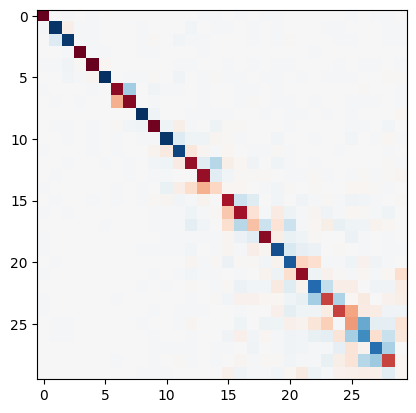

In [10]:
import matplotlib.pyplot as plt

plt.imshow(result.fmap12, cmap="RdBu")

# ZoomOut Matcher
If we want a more precise solution.


In [11]:
from geomfum.descriptor.pipeline import ArangeSubsampler, DescriptorPipeline
from geomfum.descriptor.spectral import LandmarkWaveKernelSignature, WaveKernelSignature
from geomfum.refine import ZoomOut

matcher = ZoomOutMatcher(
    descriptor_pipeline=DescriptorPipeline(
        [
            WaveKernelSignature(n_domain=200, k=200),
            LandmarkWaveKernelSignature(n_domain=200, k=200),
            ArangeSubsampler(subsample_step=10),
        ]
    ),
    refiner=ZoomOut(nit=20, step=5),
)
result = matcher(mesh_a, mesh_b)

result.p2p21.shape

(6890,)

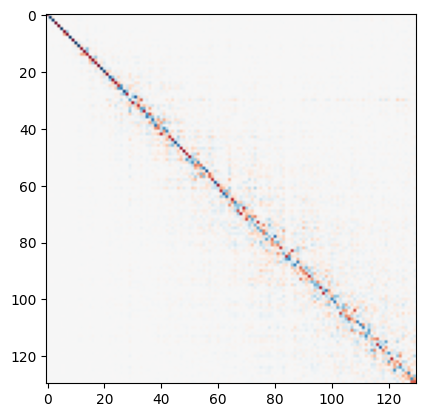

In [12]:
plt.imshow(result.refined_fmap12, cmap="RdBu")

## Further reading

* [How to compute a functional map?](./07_functional_map.ipynb)

* [How to refine a functional map?](./15_refine_functional_map.ipynb)

* [How to create a descriptor pipeline?](./04_descriptor_pipeline.ipynb)

* [How to set landmarks?](./06_landmarks.ipynb)